# Pol II pools model

## Model equations

The model describes the transitions of Pol II between three states: Nucleoplasmic (N), Paused (P), and Elongating (E). The dynamics are governed by a system of ordinary differential equations (ODEs):

$$
\frac{dN}{dt} = k_{PN}P + k_{EN}E - \frac{V_{max,NP}N}{K_{m,NP} + N}
$$

$$
\frac{dP}{dt} = \frac{V_{max,NP}N}{K_{m,NP} + N} - k_{PN}P - \frac{V_{max,PE}P}{K_{m,PE} + P}
$$

$$
\frac{dE}{dt} = \frac{V_{max,PE}P}{K_{m,PE} + P} - k_{EN}E
$$

The transition from N to P and P to E uses Michaelis-Menten kinetics. The reverse transitions (P→N and E→N) are first-order.

![States](diagram/state_diagram.png)

When the system is at steady-state,

$$
\frac{dN}{dt} = \frac{dP}{dt} = \frac{dE}{dt} = 0.
$$

Adding the constraint that the total amount of Pol II is conserved:

$$
N + P + E = T
$$

gives the following set of equations that can be solved numerically to find the steady-state concentrations of $N$, $P$, and $E$ for a given total Pol II level, $T$:

1.  $N + P + E - T = 0$
2.  $\frac{V_{max,PE}P}{K_{m,PE} + P} - k_{EN}E = 0$
3.  $\frac{V_{max,NP}N}{K_{m,NP} + N} - k_{PN}P - \frac{V_{max,PE}P}{K_{m,PE} + P} = 0$

The fitting process involves finding the parameters ($k_{PN}, k_{EN}, V_{max,PE}, K_{m,PE}, V_{max,NP}, K_{m,NP}$) across different values of $T$.

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize, root
from scipy.linalg import norm
from scipy.integrate import solve_ivp

## Load experimental data

In [2]:
try:
    # 1. Load T and E fold-change data from CSV files

    # --- Biallelic degron ---

    # Normalise by dividing by the mean of the control condition
    # (0 hours) for each dataset to get fold-change
    # relative to control
    data_path_1 = "../data/mACPOLR2A_pSer2PolII_8hours_Values_ByExperiment_3reps.csv"
    exp_data_1 = pd.read_csv(data_path_1)
    control_data_1 = exp_data_1[
        (exp_data_1["AUXIN_CONCENTRATION_nM"] == 0)
        & (exp_data_1["TIME_IN_AUXIN_HRS"] == 0)
    ]
    T_baseline_1 = control_data_1["Total_PolII_F12_Normed"].mean()
    E_baseline_1 = control_data_1["pSer2_PolII_3E10_Normed"].mean()
    T_fc_1 = (exp_data_1["Total_PolII_F12_Normed"] / T_baseline_1).values
    E_fc_1 = (exp_data_1["pSer2_PolII_3E10_Normed"] / E_baseline_1).values

    # Extract date/experiment identifier
    if "DATE" in exp_data_1.columns:
        E_date_1 = exp_data_1["DATE"].astype(str).values
    elif "EXPERIMENT" in exp_data_1.columns:
        E_date_1 = exp_data_1["EXPERIMENT"].astype(str).values
    else:
        E_date_1 = np.array(["mACPOLR2A"] * len(E_fc_1))

    # --- mACmChPOLR2A Active PolII ---

    # Normalise by dividing by the mean of the control condition
    # (0 hours) for each dataset to get fold-change
    # relative to control
    data_path_2 = "../data/mACmChPOLR2A_ActivePolII_Values_ByExperiment.csv"
    exp_data_2 = pd.read_csv(data_path_2)
    control_data_2 = exp_data_2[exp_data_2["TIME_IN_AUXIN_H"] == 0]
    T_baseline_2 = control_data_2["Total_PolII_F12_Normed"].mean()
    E_baseline_2 = control_data_2["pSer2_PolII_3E10_Normed"].mean()
    T_fc_2 = (exp_data_2["Total_PolII_F12_Normed"] / T_baseline_2).values
    E_fc_2 = (exp_data_2["pSer2_PolII_3E10_Normed"] / E_baseline_2).values

    # Extract date/experiment identifier
    if "DATE" in exp_data_2.columns:
        E_date_2 = exp_data_2["DATE"].astype(str).values
    elif "EXPERIMENT" in exp_data_2.columns:
        E_date_2 = exp_data_2["EXPERIMENT"].astype(str).values
    else:
        E_date_2 = np.array(["mACmChPOLR2A"] * len(E_fc_2))

    # --- ARMC5 ---
    data_path_3A = "../data/ARMC5_mAC_Clone5A_TotalPolII_Values_ByExperiment_3reps.csv"
    data_path_3B = "../data/ARMC5_mAC_Clone5A1_Phospho_Values_ByExperiment_3reps.csv"
    exp_data_3A = pd.read_csv(data_path_3A)
    exp_data_3B = pd.read_csv(data_path_3B)

    # Average across experiments at each timepoint, then merge on timepoint
    T_by_time = (
        exp_data_3A.groupby("TIME_IN_AUXIN_H")["Total_PolII_F12_Normed"]
        .agg(["mean", "std"])
        .reset_index()
    )
    E_by_time = (
        exp_data_3B.groupby("TIME_IN_AUXIN_H")["pSer2_PolII_3E10_Normed"]
        .agg(["mean", "std"])
        .reset_index()
    )
    exp_data_3 = T_by_time.merge(E_by_time, on="TIME_IN_AUXIN_H", suffixes=("_T", "_E"))

    control_3 = exp_data_3[exp_data_3["TIME_IN_AUXIN_H"] == 0]
    T_baseline_3 = control_3["mean_T"].mean()
    E_baseline_3 = control_3["mean_E"].mean()

    T_fc_3 = (exp_data_3["mean_T"] / T_baseline_3).values
    E_fc_3 = (exp_data_3["mean_E"] / E_baseline_3).values
    E_fc_3_sd = (exp_data_3["std_E"] / E_baseline_3).values
    E_date_3 = np.array(["ARMC5"] * len(E_fc_3))

    # --- Combine the E fold-change (E_fc) datasets ---
    # check that lengths of all T_fc and E_fc match
    if not (
        len(T_fc_1) == len(E_fc_1)
        and len(T_fc_2) == len(E_fc_2)
        and len(T_fc_3) == len(E_fc_3)
    ):
        raise ValueError("Length mismatch between T_fc and E_fc datasets.")
    T_E_fc = np.concatenate([T_fc_1, T_fc_2, T_fc_3])
    E_fc_data = np.concatenate([E_fc_1, E_fc_2, E_fc_3])
    E_dates = np.concatenate([E_date_1, E_date_2, E_date_3])

    # 2. Load bound fraction data from FRAP experiments

    # --- mChPOLR2A (mACmCh background) ---
    bound_fraction_mCh_mACmCh_path = "../data/mACmChPOLR2A_FRAP_Amounts_perday.csv"
    bound_fraction_mCh_mACmCh_df = pd.read_csv(bound_fraction_mCh_mACmCh_path)
    bound_fraction_mCh_mACmCh_df = bound_fraction_mCh_mACmCh_df[
        bound_fraction_mCh_mACmCh_df["CONDITION"] != "mACmChPOLR2A VEH"
    ]
    T_bound_1 = bound_fraction_mCh_mACmCh_df["RELATIVE_TOTAL"].values / 100.0
    bound_frac_1 = bound_fraction_mCh_mACmCh_df["BOUND_FRACTION"].values
    bound_exp_1 = np.array(["mChPOLR2A (mACmCh)"] * len(T_bound_1))

    # --- mACPOLR2A (mACmCh background) ---
    bound_fraction_mAC_mACmCh_path = (
        "../data/mACmChPOLR2A_mClover3_FRAP_Amounts_perday.csv"
    )
    bound_fraction_mAC_mACmCh_df = pd.read_csv(bound_fraction_mAC_mACmCh_path)
    bound_fraction_mAC_mACmCh_df = bound_fraction_mAC_mACmCh_df[
        bound_fraction_mAC_mACmCh_df["CONDITION"] == "mACPOLR2A VEH"
    ]
    bound_fraction_mAC_mACmCh_df = bound_fraction_mAC_mACmCh_df.rename(
        columns={"BOUND": "BOUND_FRACTION"}
    )
    T_bound_2 = bound_fraction_mAC_mACmCh_df["RELATIVE_TOTAL"].values / 100.0
    bound_frac_2 = bound_fraction_mAC_mACmCh_df["BOUND_FRACTION"].values / 100.0
    bound_exp_2 = np.array(["mACPOLR2A (mACmCh)"] * len(T_bound_2))

    # --- mACPOLR2A biallelic ---
    bound_fraction_mAC_path = (
        "../data/mACPOLR2A_biallelic_FRAP_Bound_Free_RelativeTotal.csv"
    )
    bound_fraction_mAC_df = pd.read_csv(bound_fraction_mAC_path)
    T_bound_3 = bound_fraction_mAC_df["RELATIVE_TOTAL"].values / 100.0
    bound_frac_3 = bound_fraction_mAC_df["BOUND_FRACTION"].values
    bound_exp_3 = np.array(["mACPOLR2A (biallelic)"] * len(T_bound_3))

    # --- ARMC5/Scrambled ---
    bound_fraction_mCh_ARMC5_path = (
        "../data/mChPOLR2A_FRAP_Scrambled_ARMC5_amounts_per_day.csv"
    )
    bound_fraction_mCh_ARMC5_df = pd.read_csv(bound_fraction_mCh_ARMC5_path)
    bound_fraction_mCh_ARMC5_df = bound_fraction_mCh_ARMC5_df[
        (bound_fraction_mCh_ARMC5_df["CONDITION"] == "ARMC5 VEHICLE")
        | (bound_fraction_mCh_ARMC5_df["CONDITION"] == "SCRAMBLED VEHICLE")
    ]
    T_bound_4 = bound_fraction_mCh_ARMC5_df["RELATIVE_TOTAL"].values / 100.0
    bound_frac_4 = bound_fraction_mCh_ARMC5_df["BOUND_FRACTION"].values
    bound_exp_4 = np.array(["ARMC5/Scrambled"] * len(T_bound_4))

    # Combine bound fraction data
    T_bound_fraction = np.concatenate([T_bound_1, T_bound_2, T_bound_3, T_bound_4])
    bound_fraction_data = np.concatenate(
        [bound_frac_1, bound_frac_2, bound_frac_3, bound_frac_4]
    )
    bound_experiment = np.concatenate(
        [bound_exp_1, bound_exp_2, bound_exp_3, bound_exp_4]
    )

except FileNotFoundError as e:
    print(f"Data file not found: {e.filename}. Halting execution.")
    raise

# 3. Define data manually for TSS Fold-Change (from Pol II ChIP in half-degron at 90 min and ARMC5 KO HEK cells)
T_P_fc = np.array([0.738, 1.0, 1.51])
P_fc_data = np.array([0.909, 1.0, 1.45])
P_experiment = np.array(["Half-degron 90min", "Control", "ARMC5 KO"])

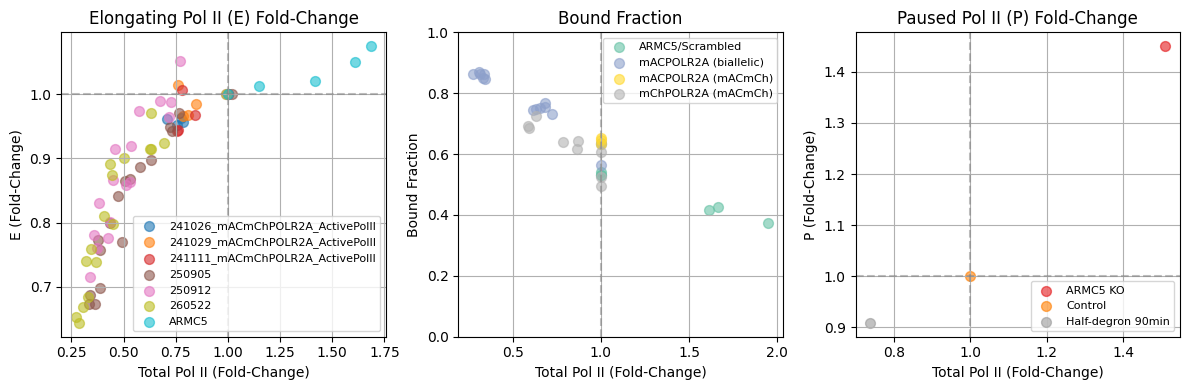

In [3]:
# Plot data
plt.figure(figsize=(12, 4))

# Define color maps for each data type
from matplotlib.colors import ListedColormap
import matplotlib.cm as cm

# Create color map for E fold-change data
E_unique = np.unique(E_dates)
E_colors = plt.cm.tab10(np.linspace(0, 1, len(E_unique)))
E_color_map = {exp: E_colors[i] for i, exp in enumerate(E_unique)}
E_point_colors = [E_color_map[exp] for exp in E_dates]

# Create color map for bound fraction data
bound_unique = np.unique(bound_experiment)
bound_colors = plt.cm.Set2(np.linspace(0, 1, len(bound_unique)))
bound_color_map = {exp: bound_colors[i] for i, exp in enumerate(bound_unique)}
bound_point_colors = [bound_color_map[exp] for exp in bound_experiment]

# Create color map for P fold-change data
P_unique = np.unique(P_experiment)
P_colors = plt.cm.Set1(np.linspace(0, 1, len(P_unique)))
P_color_map = {exp: P_colors[i] for i, exp in enumerate(P_unique)}
P_point_colors = [P_color_map[exp] for exp in P_experiment]

# Subplot 1: E fold-change data
plt.subplot(1, 3, 1)
for exp in E_unique:
    mask = E_dates == exp
    plt.scatter(
        T_E_fc[mask],
        E_fc_data[mask],
        alpha=0.6,
        color=E_color_map[exp],
        label=exp,
        s=50,
    )
plt.title("Elongating Pol II (E) Fold-Change")
plt.xlabel("Total Pol II (Fold-Change)")
plt.ylabel("E (Fold-Change)")
plt.grid(True)
plt.axhline(1, color="grey", linestyle="--", alpha=0.5)
plt.axvline(1, color="grey", linestyle="--", alpha=0.5)
plt.legend(fontsize=8)

# Subplot 2: Bound fraction data
plt.subplot(1, 3, 2)
for exp in bound_unique:
    mask = bound_experiment == exp
    plt.scatter(
        T_bound_fraction[mask],
        bound_fraction_data[mask],
        alpha=0.6,
        color=bound_color_map[exp],
        label=exp,
        s=50,
    )
plt.title("Bound Fraction")
plt.xlabel("Total Pol II (Fold-Change)")
plt.ylabel("Bound Fraction")
plt.grid(True)
plt.axvline(1, color="grey", linestyle="--", alpha=0.5)
plt.legend(fontsize=8)
plt.ylim(0, 1)

# Subplot 3: Paused fold-change data
plt.subplot(1, 3, 3)
for exp in P_unique:
    mask = P_experiment == exp
    plt.scatter(
        T_P_fc[mask],
        P_fc_data[mask],
        alpha=0.6,
        color=P_color_map[exp],
        label=exp,
        s=50,
    )
plt.title("Paused Pol II (P) Fold-Change")
plt.xlabel("Total Pol II (Fold-Change)")
plt.ylabel("P (Fold-Change)")
plt.grid(True)
plt.axhline(1, color="grey", linestyle="--", alpha=0.5)
plt.axvline(1, color="grey", linestyle="--", alpha=0.5)
plt.legend(fontsize=8)

plt.tight_layout()
plt.show()

## Define equations and solver

In [4]:
def steady_state_equations(vars, T, params):
    """
    Defines the system of equations for steady-state.
    Now uses first-order kinetics for P→N transition.
    """
    N, P, E = vars
    k_pn, Vmax_pe, Km_pe, Vmax_np, Km_np = params
    k_en = 1.0

    eq1 = N + P + E - T
    eq2 = (Vmax_pe * P) / (Km_pe + P) - k_en * E
    eq3 = (Vmax_np * N) / (Km_np + N) - k_pn * P - (Vmax_pe * P) / (Km_pe + P)

    return [eq1, eq2, eq3]

In [5]:
def get_steady_state(T, params, previous_solution=None, tolerance=1e-8):
    """
    Robust solver for steady-state system.

    Parameters:
    -----------
    T : float
        Total Pol II concentration
    params : list or array-like
        Model parameters [k_pn, Vmax_pe, Km_pe, Vmax_np, Km_np]
    previous_solution : list, optional
        Previous solution to use as initial guess for continuity
    tolerance : float
        Tolerance for solution validation

    Returns:
    --------
    dict
        Dictionary containing:
        - 'solution': [N, P, E] concentrations
        - 'converged': bool indicating if solution converged
        - 'stable': bool indicating if solution appears stable
        - 'residual_norm': float, norm of residual equations
    """

    # Multiple initial guesses to test for uniqueness
    if previous_solution is not None:
        # Use previous solution as primary guess (continuation)
        initial_guesses = [previous_solution]
        # Add some nearby guesses for validation
        delta = 0.1 * T
        initial_guesses.extend(
            [
                [
                    max(0, previous_solution[0] + delta),
                    max(0, previous_solution[1]),
                    max(0, previous_solution[2] - delta),
                ],
                [
                    max(0, previous_solution[0] - delta),
                    max(0, previous_solution[1] + delta),
                    max(0, previous_solution[2]),
                ],
            ]
        )
    else:
        # Standard set of diverse initial guesses
        initial_guesses = [
            [T * 0.5, T * 0.3, T * 0.2],  # Balanced distribution
            [T * 0.7, T * 0.2, T * 0.1],  # N-heavy
            [T * 0.2, T * 0.6, T * 0.2],  # P-heavy
            [T * 0.1, T * 0.2, T * 0.7],  # E-heavy
            [T * 0.8, T * 0.15, T * 0.05],  # Mostly unbound
            [T * 0.33, T * 0.33, T * 0.34],  # Equal distribution
        ]

    solutions = []
    residuals = []

    # Try each initial guess
    for i, guess in enumerate(initial_guesses):
        try:
            # Use root with multiple methods for robustness
            methods = (
                ["hybr", "lm"] if i == 0 else ["hybr"]
            )  # Use Levenberg-Marquardt for first guess

            for method in methods:
                try:
                    result = root(
                        steady_state_equations,
                        guess,
                        args=(T, params),
                        method=method,
                        options={"xtol": tolerance},
                    )

                    if result.success:
                        N, P, E = result.x

                        # Validate solution
                        if (
                            N >= -tolerance
                            and P >= -tolerance
                            and E >= -tolerance
                            and abs(N + P + E - T) < tolerance
                        ):

                            residual_norm = norm(result.fun)
                            solutions.append((result.x, residual_norm))
                            residuals.append(residual_norm)
                            break  # Found good solution with this guess

                except Exception:
                    continue  # Try next method or guess

        except Exception:
            continue  # Try next guess

    if not solutions:
        return {
            "solution": [np.nan, np.nan, np.nan],
            "converged": False,
            "stable": False,
            "residual_norm": np.inf,
        }

    # Find best solution (lowest residual)
    best_idx = np.argmin(residuals)
    best_solution, best_residual = solutions[best_idx]

    # Check for solution uniqueness (stability indicator)
    stable = True
    if len(solutions) > 1:
        # Compare all solutions to see if they're essentially the same
        for sol, _ in solutions:
            if (
                norm(sol - best_solution) > tolerance * 10
            ):  # Allow some numerical difference
                stable = False
                warnings.warn(
                    f"Multiple distinct solutions found for T={T:.4f}. "
                    f"This may indicate parameter identifiability issues."
                )
                break

    return {
        "solution": best_solution.tolist(),
        "converged": True,
        "stable": stable,
        "residual_norm": best_residual,
    }

## Objective Function and Model Fitting

Fit the model to three types of experimental data:
1. **Elongating Pol II (E) fold-change** vs Total Pol II 
2. **Bound fraction** vs Total Pol II
3. **Paused Pol II (P) fold-change** vs Total Pol II

**Additional Constraint:**
At T=1, the flux through P→N transitions should be 4× the flux through P→E transitions:
- Flux P→N = $k_{PN} \times P$ 
- Flux P→E = $(V_{max,PE} \times P) / (K_{m,PE} + P)$
- Constraint: $k_{PN} \times P = 4 \times (V_{max,PE} \times P) / (K_{m,PE} + P)$ at T=1

In [6]:
def objective_function(params, apply_constraint=True, constraint_weight=100.0):
    """
    Objective function for fitting the model to experimental data.

    Parameters:
    -----------
    params : array-like
        Model parameters [k_pn, Vmax_pe, Km_pe, Vmax_np, Km_np]
    apply_constraint : bool
        Whether to apply the flux ratio constraint at T=1
    constraint_weight : float
        Weight for the constraint penalty term

    Returns:
    --------
    float
        Total weighted residual
    """

    # Unpack parameters
    k_pn, Vmax_pe, Km_pe, Vmax_np, Km_np = params

    # Parameter bounds checking (return large penalty if out of bounds)
    if (
        k_pn <= 0
        or Vmax_pe <= 0
        or Km_pe <= 0
        or Vmax_np <= 0
        or Km_np <= 0
        or k_pn > 10
        or Vmax_pe > 20
        or Km_pe > 10
        or Vmax_np > 20
        or Km_np > 10
    ):
        return 1e6

    total_residual = 0.0
    n_data_points = 0

    # 1. Fit E fold-change data
    try:
        # Get baseline solution at T=1 for fold-change calculations
        T_baseline = 1.0
        baseline_result = get_steady_state(T_baseline, params)
        if not baseline_result["converged"] or not baseline_result["stable"]:
            return 1e6

        N_base, P_base, E_base = baseline_result["solution"]

        # Calculate model predictions for E fold-change
        E_model_predictions = []
        for T_val in T_E_fc:
            result = get_steady_state(T_val, params)
            if result["converged"] and result["stable"]:
                N, P, E = result["solution"]
                E_fc_pred = E / E_base if E_base > 0 else 0
                E_model_predictions.append(E_fc_pred)
            else:
                return 1e6  # Penalize failed solutions

        E_model_predictions = np.array(E_model_predictions)

        # Inverse-variance weights for ARMC5 averaged points
        # Add small epsilon to avoid division by zero if SD happens to be 0
        epsilon = 1e-6
        armc5_weights = 1.0 / (E_fc_3_sd**2 + epsilon)

        # Normalise so the mean ARMC5 weight equals 3.0
        # (upweighting ARMC5 data to match actual replicate number)
        armc5_weights = armc5_weights / armc5_weights.mean() * 3.0

        weights = np.concatenate(
            [
                np.ones(len(T_fc_1)),
                np.ones(len(T_fc_2)),
                armc5_weights,
            ]
        )
        E_residuals = weights * (E_model_predictions - E_fc_data) ** 2
        total_residual += np.sum(E_residuals)
        n_data_points += np.sum(weights)

    except Exception:
        return 1e6

    # 2. Fit bound fraction data
    try:
        bound_fraction_predictions = []
        for T_val in T_bound_fraction:
            result = get_steady_state(T_val, params)
            if result["converged"] and result["stable"]:
                N, P, E = result["solution"]
                bound_fraction_pred = (P + E) / T_val if T_val > 0 else 0
                bound_fraction_predictions.append(bound_fraction_pred)
            else:
                return 1e6

        bound_fraction_predictions = np.array(bound_fraction_predictions)
        bound_residuals = (bound_fraction_predictions - bound_fraction_data) ** 2
        total_residual += np.sum(bound_residuals)
        n_data_points += len(bound_residuals)

    except Exception:
        return 1e6

    # 3. Fit P fold-change data
    try:
        P_model_predictions = []
        for T_val in T_P_fc:
            result = get_steady_state(T_val, params)
            if result["converged"] and result["stable"]:
                N, P, E = result["solution"]
                P_fc_pred = P / P_base if P_base > 0 else 0
                P_model_predictions.append(P_fc_pred)
            else:
                return 1e6

        P_model_predictions = np.array(P_model_predictions)
        P_residuals = (P_model_predictions - P_fc_data) ** 2
        total_residual += np.sum(P_residuals)
        n_data_points += len(P_residuals)

    except Exception:
        return 1e6

    # 4. Apply flux ratio constraint at T=1
    if apply_constraint:
        try:
            # At T=1, flux P->N should be 4x flux P->E
            # Flux P->N = k_pn * P_base
            # Flux P->E = (Vmax_pe * P_base) / (Km_pe + P_base)

            flux_pn = k_pn * P_base
            flux_pe = (Vmax_pe * P_base) / (Km_pe + P_base)

            # Constraint: flux_pn = 4 * flux_pe
            constraint_residual = (flux_pn - 4 * flux_pe) ** 2
            total_residual += constraint_weight * constraint_residual

        except Exception:
            return 1e6

    # Return normalized residual
    if n_data_points > 0:
        return total_residual / n_data_points
    else:
        return 1e6


def fit_model(
    initial_params=None,
    apply_constraint=True,
    constraint_weight=100.0,
    method="L-BFGS-B",
):
    """
    Fit the model parameters to experimental data.

    Parameters:
    -----------
    initial_params : array-like, optional
        Initial parameter guess [k_pn, Vmax_pe, Km_pe, Vmax_np, Km_np]
    apply_constraint : bool
        Whether to apply the flux ratio constraint
    constraint_weight : float
        Weight for constraint penalty
    method : str
        Optimization method

    Returns:
    --------
    dict
        Fitting results including optimal parameters and diagnostics
    """

    # Set default initial parameters if not provided
    if initial_params is None:
        initial_params = [
            1.0,
            3.0,
            1.0,
            2.0,
            1.0,
        ]  # [k_pn, Vmax_pe, Km_pe, Vmax_np, Km_np]

    # Parameter bounds (all positive, reasonable ranges)
    bounds = [(0.01, 10), (0.01, 20), (0.01, 10), (0.01, 20), (0.01, 10)]

    # Multiple random initial guesses to avoid local minima
    best_result = None
    best_cost = np.inf

    n_attempts = 10
    np.random.seed(42)  # For reproducibility

    print(f"Fitting model with {n_attempts} different initial conditions...")
    print(f"Constraint applied: {apply_constraint}, Weight: {constraint_weight}")
    print()

    for attempt in range(n_attempts):
        if attempt == 0:
            # Use provided initial guess
            current_initial = initial_params
        else:
            # Generate random initial parameters within bounds
            current_initial = [np.random.uniform(b[0], b[1]) for b in bounds]

        try:
            # Perform optimization
            result = minimize(
                objective_function,
                current_initial,
                args=(apply_constraint, constraint_weight),
                method=method,
                bounds=bounds,
                options={"maxiter": 1000},
            )

            if result.success and result.fun < best_cost:
                best_cost = result.fun
                best_result = result

        except Exception as e:
            print(f"Attempt {attempt + 1} failed: {e}")
            continue

    if best_result is None:
        return {"success": False, "message": "All optimization attempts failed"}

    # Extract best parameters
    k_pn_opt, Vmax_pe_opt, Km_pe_opt, Vmax_np_opt, Km_np_opt = best_result.x

    # Calculate some diagnostics
    final_cost = best_result.fun

    # Test constraint satisfaction at T=1
    baseline_result = get_steady_state(1.0, best_result.x)
    if baseline_result["converged"]:
        N_base, P_base, E_base = baseline_result["solution"]
        flux_pn = k_pn_opt * P_base
        flux_pe = (Vmax_pe_opt * P_base) / (Km_pe_opt + P_base)
        flux_ratio = flux_pn / flux_pe if flux_pe > 0 else np.inf
    else:
        flux_ratio = np.nan

    return {
        "success": True,
        "optimal_params": best_result.x,
        "final_cost": final_cost,
        "optimization_result": best_result,
        "flux_ratio_at_T1": flux_ratio,
        "target_flux_ratio": 4.0,
        "constraint_satisfied": (
            abs(flux_ratio - 4.0) < 0.1 if not np.isnan(flux_ratio) else False
        ),
    }

## Model fitting

In [7]:
# Fit the model
print("Fitting with flux ratio constraint (P→N = 4× P→E at T=1):")
fit_result_constrained = fit_model(
    initial_params=[1.0, 3.0, 1.0, 2.0, 1.0],
    apply_constraint=True,
    constraint_weight=100.0,
    method="L-BFGS-B",
)

if fit_result_constrained["success"]:
    params_opt = fit_result_constrained["optimal_params"]
    k_pn, Vmax_pe, Km_pe, Vmax_np, Km_np = params_opt

    print(f"✓ Optimization successful!")
    print(f"Optimal parameters:")
    print(f"  k_pn = {k_pn:.4f}")
    print(f"  Vmax_pe = {Vmax_pe:.4f}")
    print(f"  Km_pe = {Km_pe:.4f}")
    print(f"  Vmax_np = {Vmax_np:.4f}")
    print(f"  Km_np = {Km_np:.4f}")
    print(f"Final cost: {fit_result_constrained['final_cost']:.6f}")
    print(
        f"Flux ratio (P→N)/(P→E) at T=1: {fit_result_constrained['flux_ratio_at_T1']:.2f}"
    )
    print(f"Target ratio: {fit_result_constrained['target_flux_ratio']:.1f}")
    print(f"Constraint satisfied: {fit_result_constrained['constraint_satisfied']}")
else:
    print(f"✗ Optimization failed: {fit_result_constrained['message']}")

Fitting with flux ratio constraint (P→N = 4× P→E at T=1):
Fitting model with 10 different initial conditions...
Constraint applied: True, Weight: 100.0

✓ Optimization successful!
Optimal parameters:
  k_pn = 4.9610
  Vmax_pe = 0.3602
  Km_pe = 0.0256
  Vmax_np = 2.7972
  Km_np = 0.2861
Final cost: 0.001657
Flux ratio (P→N)/(P→E) at T=1: 4.00
Target ratio: 4.0
Constraint satisfied: True


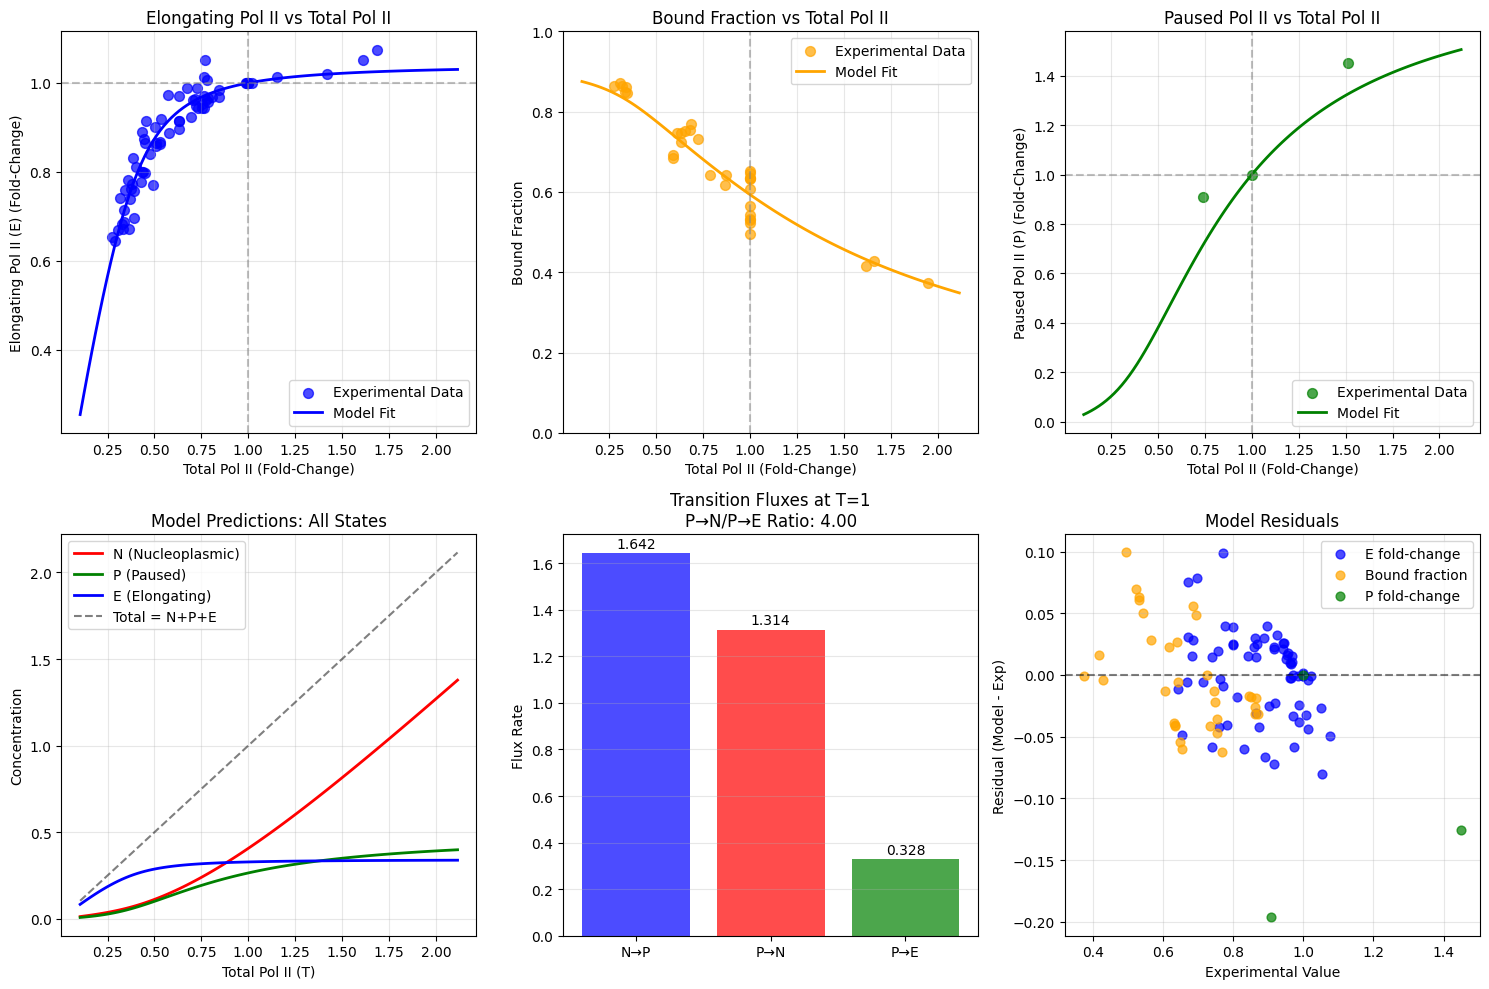

MODEL FIT SUMMARY:
Final cost (MSE): 0.001657
E fold-change RMSE: 0.0345
Bound fraction RMSE: 0.0419
P fold-change RMSE: 0.1346
Flux ratio constraint: 4.00 (target: 4.0)


In [8]:
if fit_result_constrained["success"]:

    # Use the constrained fit parameters
    optimal_params = fit_result_constrained["optimal_params"]

    # Determine the data range with 10% margins
    all_T_data = np.concatenate([T_E_fc, T_bound_fraction, T_P_fc])
    T_min = np.min(all_T_data)
    T_max = np.max(all_T_data)
    margin = 0.1 * (T_max - T_min)
    T_range_min = max(0.1, T_min - margin)  # Don't go below 0.1
    T_range_max = T_max + margin

    # Generate model predictions across the data range + margin
    T_range = np.linspace(T_range_min, T_range_max, 100)
    model_solutions = []

    # Get baseline at T=1 for fold-change calculations
    baseline_result = get_steady_state(1.0, optimal_params)
    N_base, P_base, E_base = baseline_result["solution"]

    # Generate predictions
    for T_val in T_range:
        result = get_steady_state(T_val, optimal_params)
        if result["converged"] and result["stable"]:
            model_solutions.append(result["solution"])
        else:
            model_solutions.append([np.nan, np.nan, np.nan])

    model_solutions = np.array(model_solutions)

    # Calculate model predictions for each data type
    E_fc_model = model_solutions[:, 2] / E_base
    P_fc_model = model_solutions[:, 1] / P_base
    bound_fraction_model = (model_solutions[:, 1] + model_solutions[:, 2]) / T_range

    # Create comprehensive comparison plots
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))

    # Plot 1: E fold-change
    axes[0, 0].scatter(
        T_E_fc, E_fc_data, alpha=0.7, color="blue", s=50, label="Experimental Data"
    )
    axes[0, 0].plot(T_range, E_fc_model, "b-", linewidth=2, label="Model Fit")
    axes[0, 0].set_xlabel("Total Pol II (Fold-Change)")
    axes[0, 0].set_ylabel("Elongating Pol II (E) (Fold-Change)")
    axes[0, 0].set_title("Elongating Pol II vs Total Pol II")
    axes[0, 0].grid(True, alpha=0.3)
    axes[0, 0].axhline(1, color="gray", linestyle="--", alpha=0.5)
    axes[0, 0].axvline(1, color="gray", linestyle="--", alpha=0.5)
    axes[0, 0].legend()

    # Plot 2: Bound fraction
    axes[0, 1].scatter(
        T_bound_fraction,
        bound_fraction_data,
        alpha=0.7,
        color="orange",
        s=50,
        label="Experimental Data",
    )
    axes[0, 1].plot(
        T_range, bound_fraction_model, "orange", linewidth=2, label="Model Fit"
    )
    axes[0, 1].set_xlabel("Total Pol II (Fold-Change)")
    axes[0, 1].set_ylabel("Bound Fraction")
    axes[0, 1].set_title("Bound Fraction vs Total Pol II")
    axes[0, 1].grid(True, alpha=0.3)
    axes[0, 1].axvline(1, color="gray", linestyle="--", alpha=0.5)
    axes[0, 1].set_ylim(0, 1)
    axes[0, 1].legend()

    # Plot 3: P fold-change
    axes[0, 2].scatter(
        T_P_fc, P_fc_data, alpha=0.7, color="green", s=50, label="Experimental Data"
    )
    axes[0, 2].plot(T_range, P_fc_model, "g-", linewidth=2, label="Model Fit")
    axes[0, 2].set_xlabel("Total Pol II (Fold-Change)")
    axes[0, 2].set_ylabel("Paused Pol II (P) (Fold-Change)")
    axes[0, 2].set_title("Paused Pol II vs Total Pol II")
    axes[0, 2].grid(True, alpha=0.3)
    axes[0, 2].axhline(1, color="gray", linestyle="--", alpha=0.5)
    axes[0, 2].axvline(1, color="gray", linestyle="--", alpha=0.5)
    axes[0, 2].legend()

    # Plot 4: All concentrations vs T
    axes[1, 0].plot(
        T_range, model_solutions[:, 0], "r-", linewidth=2, label="N (Nucleoplasmic)"
    )
    axes[1, 0].plot(
        T_range, model_solutions[:, 1], "g-", linewidth=2, label="P (Paused)"
    )
    axes[1, 0].plot(
        T_range, model_solutions[:, 2], "b-", linewidth=2, label="E (Elongating)"
    )
    axes[1, 0].plot(T_range, T_range, "k--", alpha=0.5, label="Total = N+P+E")
    axes[1, 0].set_xlabel("Total Pol II (T)")
    axes[1, 0].set_ylabel("Concentration")
    axes[1, 0].set_title("Model Predictions: All States")
    axes[1, 0].grid(True, alpha=0.3)
    axes[1, 0].legend()

    # Plot 5: Flux analysis at T=1
    k_pu, Vmax_pe, Km_pe, Vmax_np, Km_np = optimal_params
    flux_pn = k_pu * P_base
    flux_pe = (Vmax_pe * P_base) / (Km_pe + P_base)
    flux_np = (Vmax_np * N_base) / (Km_np + N_base)

    fluxes = [flux_np, flux_pn, flux_pe]
    flux_labels = ["N→P", "P→N", "P→E"]
    colors = ["blue", "red", "green"]

    bars = axes[1, 1].bar(flux_labels, fluxes, color=colors, alpha=0.7)
    axes[1, 1].set_ylabel("Flux Rate")
    axes[1, 1].set_title(
        f"Transition Fluxes at T=1\nP→N/P→E Ratio: {flux_pn/flux_pe:.2f}"
    )
    axes[1, 1].grid(True, alpha=0.3, axis="y")

    # Add value labels on bars
    for bar, flux in zip(bars, fluxes):
        height = bar.get_height()
        axes[1, 1].text(
            bar.get_x() + bar.get_width() / 2.0,
            height + 0.01,
            f"{flux:.3f}",
            ha="center",
            va="bottom",
        )

    # Plot 6: Residuals analysis
    # Calculate residuals for each data type
    E_pred_at_data = []
    for T_val in T_E_fc:
        result = get_steady_state(T_val, optimal_params)
        if result["converged"]:
            E_pred_at_data.append(result["solution"][2] / E_base)
        else:
            E_pred_at_data.append(np.nan)

    bound_pred_at_data = []
    for T_val in T_bound_fraction:
        result = get_steady_state(T_val, optimal_params)
        if result["converged"]:
            N, P, E = result["solution"]
            bound_pred_at_data.append((P + E) / T_val)
        else:
            bound_pred_at_data.append(np.nan)

    P_pred_at_data = []
    for T_val in T_P_fc:
        result = get_steady_state(T_val, optimal_params)
        if result["converged"]:
            P_pred_at_data.append(result["solution"][1] / P_base)
        else:
            P_pred_at_data.append(np.nan)

    E_residuals = np.array(E_pred_at_data) - E_fc_data
    bound_residuals = np.array(bound_pred_at_data) - bound_fraction_data
    P_residuals = np.array(P_pred_at_data) - P_fc_data

    axes[1, 2].scatter(
        E_fc_data, E_residuals, alpha=0.7, color="blue", label="E fold-change", s=40
    )
    axes[1, 2].scatter(
        bound_fraction_data,
        bound_residuals,
        alpha=0.7,
        color="orange",
        label="Bound fraction",
        s=40,
    )
    axes[1, 2].scatter(
        P_fc_data, P_residuals, alpha=0.7, color="green", label="P fold-change", s=40
    )
    axes[1, 2].axhline(0, color="black", linestyle="--", alpha=0.5)
    axes[1, 2].set_xlabel("Experimental Value")
    axes[1, 2].set_ylabel("Residual (Model - Exp)")
    axes[1, 2].set_title("Model Residuals")
    axes[1, 2].grid(True, alpha=0.3)
    axes[1, 2].legend()

    plt.tight_layout()
    plt.show()

    # Print summary statistics
    print("MODEL FIT SUMMARY:")
    print("=" * 50)
    print(f"Final cost (MSE): {fit_result_constrained['final_cost']:.6f}")
    print(f"E fold-change RMSE: {np.sqrt(np.nanmean(E_residuals**2)):.4f}")
    print(f"Bound fraction RMSE: {np.sqrt(np.nanmean(bound_residuals**2)):.4f}")
    print(f"P fold-change RMSE: {np.sqrt(np.nanmean(P_residuals**2)):.4f}")
    print(f"Flux ratio constraint: {flux_pn/flux_pe:.2f} (target: 4.0)")

else:
    print("Cannot plot results - model fitting failed")

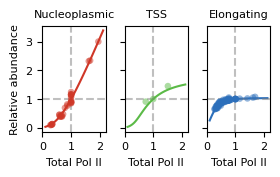

In [9]:
# Publication plot: Individual States with Experimental Data
if fit_result_constrained["success"]:

    # Use the constrained fit parameters
    optimal_params = fit_result_constrained["optimal_params"]

    # Determine the data range with 10% margins
    all_T_data = np.concatenate([T_E_fc, T_bound_fraction, T_P_fc])
    T_min = np.min(all_T_data)
    T_max = np.max(all_T_data)
    margin = 0.1 * (T_max - T_min)
    T_range_min = max(0.1, T_min - margin)  # Don't go below 0.1
    T_range_max = T_max + margin

    # Generate model predictions across the data range + margin
    T_range = np.linspace(T_range_min, T_range_max, 100)
    model_solutions = []

    # Get baseline at T=1 for normalization
    baseline_result = get_steady_state(1.0, optimal_params)
    N_base, P_base, E_base = baseline_result["solution"]

    # Generate predictions
    for T_val in T_range:
        result = get_steady_state(T_val, optimal_params)
        if result["converged"] and result["stable"]:
            model_solutions.append(result["solution"])
        else:
            model_solutions.append([np.nan, np.nan, np.nan])

    model_solutions = np.array(model_solutions)

    # Normalize to T=1 levels
    N_normalized = model_solutions[:, 0] / N_base
    P_normalized = model_solutions[:, 1] / P_base
    E_normalized = model_solutions[:, 2] / E_base

    # Prepare experimental data
    # Nucleoplasmic data: (1 - bound_fraction) * T, normalized to T=1 level
    N_exp_data = (1 - bound_fraction_data) * T_bound_fraction
    N_exp_normalized = N_exp_data / N_base

    # TSS (Paused) data: already have P_fc_data which are fold-changes
    P_exp_normalized = P_fc_data  # Already normalized fold-changes

    # Elongating data: already have E_fc_data which are fold-changes
    E_exp_normalized = E_fc_data  # Already normalized fold-changes

    # Create the three-panel plot with data
    # Convert cm to inches (1 cm = 0.393701 inches)
    cm_to_inch = 0.393701
    fig, axes = plt.subplots(
        1, 3, figsize=(8.75 * cm_to_inch, 3.5 * cm_to_inch), sharey=True
    )
    plt.subplots_adjust(wspace=-0.2, hspace=0)

    # Plot N (Nucleoplasmic) with data
    axes[0].plot(T_range, N_normalized, "#cf3727", linewidth=1.5)
    axes[0].scatter(
        T_bound_fraction,
        N_exp_normalized,
        color="#cf3727",
        s=22.5,
        alpha=0.5,
        zorder=5,
        edgecolors="none",
    )
    axes[0].set_xlabel("Total Pol II", fontsize=8)
    axes[0].set_ylabel("Relative abundance", fontsize=8)
    axes[0].set_title("Nucleoplasmic", fontsize=8)
    axes[0].set_xticks([0, 1, 2])
    axes[0].tick_params(axis="both", labelsize=8)
    axes[0].axvline(x=1, color="gray", linestyle="--", alpha=0.5)

    # Plot P (TSS) with data
    axes[1].plot(T_range, P_normalized, "#5bba47", linewidth=1.5)
    axes[1].scatter(
        T_P_fc,
        P_exp_normalized,
        color="#5bba47",
        s=22.5,
        alpha=0.5,
        zorder=5,
        edgecolors="none",
    )
    axes[1].set_xlabel("Total Pol II", fontsize=8)
    axes[1].set_title("TSS", fontsize=8)
    axes[1].set_xticks([0, 1, 2])
    axes[1].tick_params(axis="both", labelsize=8)
    axes[1].axvline(x=1, color="gray", linestyle="--", alpha=0.5)

    # Plot E (Elongating) with data
    axes[2].plot(T_range, E_normalized, "xkcd:medium blue", linewidth=1.5)
    axes[2].scatter(
        T_E_fc,
        E_exp_normalized,
        color="xkcd:medium blue",
        s=22.5,
        alpha=0.5,
        zorder=5,
        edgecolors="none",
    )
    axes[2].set_xlabel("Total Pol II", fontsize=8)
    axes[2].set_title("Elongating", fontsize=8)
    axes[2].set_xticks([0, 1, 2])
    axes[2].tick_params(axis="both", labelsize=8)
    axes[2].axvline(x=1, color="gray", linestyle="--", alpha=0.5)

    # Set y-axis ticks for the shared y-axis
    axes[0].set_yticks([0, 1, 2, 3])

    # Add horizontal reference line at y=1 for all subplots
    for ax in axes:
        ax.axhline(y=1, color="gray", linestyle="--", alpha=0.5)
        ax.set_aspect("equal", adjustable="box")

    # Save as PDF
    plt.savefig(
        "pol_ii_individual_states_with_data.pdf",
        dpi=300,
        bbox_inches="tight",
        format="pdf",
    )

    plt.show()

else:
    print("Cannot create plot - model fitting failed")

## Validate steady-state solution using numerical integration

Validating steady-state solutions using ODE simulation:

T = 0.5:
  Analytical steady-state: N=0.1120, P=0.1008, E=0.2872
  ODE simulation result: N=0.1120, P=0.1008, E=0.2872
  Mass conservation error: 1.11e-16
  Max steady-state error: 3.52e-10
  ✓ Validation successful (error < 1e-06)

T = 1.0:
  Analytical steady-state: N=0.4067, P=0.2648, E=0.3284
  ODE simulation result: N=0.4067, P=0.2648, E=0.3284
  Mass conservation error: 1.11e-16
  Max steady-state error: 9.88e-10
  ✓ Validation successful (error < 1e-06)

T = 1.5:
  Analytical steady-state: N=0.8147, P=0.3497, E=0.3356
  ODE simulation result: N=0.8147, P=0.3497, E=0.3356
  Mass conservation error: 2.22e-16
  Max steady-state error: 5.48e-10
  ✓ Validation successful (error < 1e-06)


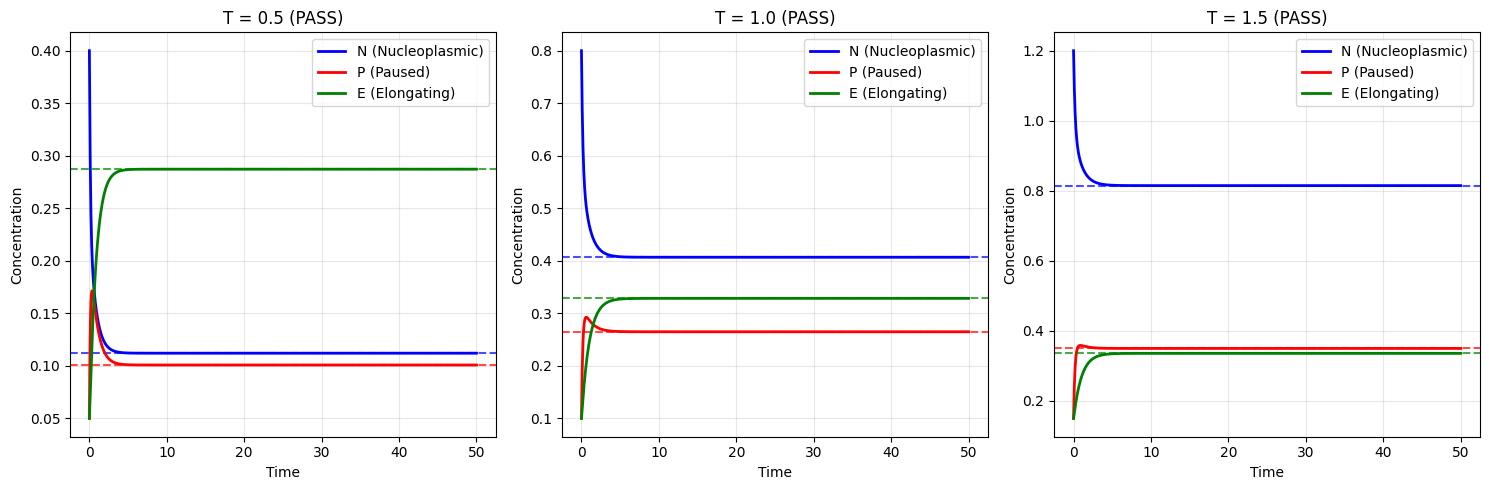

In [10]:
# Validate steady-state solutions using ODE simulation


def pol_ii_odes(t, y, params, T_total):
    """
    System of ODEs for Pol II dynamics.

    Parameters:
    -----------
    t : float
        Time
    y : array
        [N, P, E] concentrations
    params : array
        Model parameters [k_pn, Vmax_pe, Km_pe, Vmax_np, Km_np]
    T_total : float
        Total Pol II concentration (conserved)

    Returns:
    --------
    array
        Time derivatives [dN/dt, dP/dt, dE/dt]
    """
    N, P, E = y
    k_pn, Vmax_pe, Km_pe, Vmax_np, Km_np = params
    k_en = 1.0

    # ODEs
    dN_dt = k_pn * P + k_en * E - (Vmax_np * N) / (Km_np + N)
    dP_dt = (Vmax_np * N) / (Km_np + N) - k_pn * P - (Vmax_pe * P) / (Km_pe + P)
    dE_dt = (Vmax_pe * P) / (Km_pe + P) - k_en * E

    return [dN_dt, dP_dt, dE_dt]


def validate_steady_state(T_values, params, t_max=50, atol=1e-6):
    """
    Validate steady-state solutions by ODE simulation.

    Parameters:
    -----------
    T_values : array
        Total Pol II values to test
    params : array
        Model parameters
    t_max : float
        Maximum simulation time
    atol : float
        Tolerance for steady-state detection

    Returns:
    --------
    dict
        Validation results
    """
    results = {}

    print("Validating steady-state solutions using ODE simulation:")
    print("=" * 60)

    for T in T_values:
        print(f"\nT = {T:.1f}:")

        # Get analytical steady-state solution
        ss_result = get_steady_state(T, params)
        if not ss_result["converged"]:
            print(f"  ✗ Analytical solution failed to converge")
            continue

        N_ss, P_ss, E_ss = ss_result["solution"]
        print(f"  Analytical steady-state: N={N_ss:.4f}, P={P_ss:.4f}, E={E_ss:.4f}")

        # Initial conditions (start away from steady-state)
        y0 = [T * 0.8, T * 0.1, T * 0.1]  # Different from steady-state

        # Simulate ODEs
        try:
            sol = solve_ivp(
                pol_ii_odes,
                [0, t_max],
                y0,
                args=(params, T),
                dense_output=True,
                rtol=1e-8,
                atol=1e-10,
            )

            if not sol.success:
                print(f"  ✗ ODE simulation failed: {sol.message}")
                continue

            # Get final values
            N_final, P_final, E_final = sol.y[:, -1]

            # Check mass conservation
            total_final = N_final + P_final + E_final
            mass_error = abs(total_final - T)

            # Check convergence to steady-state
            N_error = abs(N_final - N_ss)
            P_error = abs(P_final - P_ss)
            E_error = abs(E_final - E_ss)
            max_error = max(N_error, P_error, E_error)

            print(
                f"  ODE simulation result: N={N_final:.4f}, P={P_final:.4f}, E={E_final:.4f}"
            )
            print(f"  Mass conservation error: {mass_error:.2e}")
            print(f"  Max steady-state error: {max_error:.2e}")

            if max_error < atol:
                print(f"  ✓ Validation successful (error < {atol:.0e})")
                validation_status = "PASS"
            else:
                print(f"  ✗ Validation failed (error = {max_error:.2e} >= {atol:.0e})")
                validation_status = "FAIL"

            # Store results
            results[T] = {
                "analytical": [N_ss, P_ss, E_ss],
                "simulated": [N_final, P_final, E_final],
                "errors": [N_error, P_error, E_error],
                "max_error": max_error,
                "mass_error": mass_error,
                "status": validation_status,
                "time_series": sol,
            }

        except Exception as e:
            print(f"  ✗ ODE simulation error: {e}")
            continue

    return results


# Validate using the fitted parameters
if fit_result_constrained["success"]:
    optimal_params = fit_result_constrained["optimal_params"]

    # Test at different T values
    test_T_values = [0.5, 1.0, 1.5]

    validation_results = validate_steady_state(test_T_values, optimal_params)

    # Plot time series for visualization
    if validation_results:
        fig, axes = plt.subplots(1, 3, figsize=(15, 5))

        colors = ["blue", "red", "green"]
        labels = ["N (Nucleoplasmic)", "P (Paused)", "E (Elongating)"]

        for i, T in enumerate(test_T_values):
            if T in validation_results:
                result = validation_results[T]
                sol = result["time_series"]

                # Plot time series
                t_plot = np.linspace(0, sol.t[-1], 1000)
                y_plot = sol.sol(t_plot)

                for j in range(3):
                    axes[i].plot(
                        t_plot, y_plot[j], colors[j], linewidth=2, label=labels[j]
                    )

                    # Mark steady-state value
                    ss_val = result["analytical"][j]
                    axes[i].axhline(ss_val, color=colors[j], linestyle="--", alpha=0.7)

                axes[i].set_xlabel("Time")
                axes[i].set_ylabel("Concentration")
                axes[i].set_title(f'T = {T:.1f} ({result["status"]})')
                axes[i].grid(True, alpha=0.3)
                axes[i].legend()

        plt.tight_layout()
        plt.show()

else:
    print("Cannot validate - model fitting failed")

## Extract best fit parameters

In [11]:
# Extract and print the best fit parameters
if fit_result_constrained["success"]:
    optimal_params = fit_result_constrained["optimal_params"]
    k_pn, Vmax_pe, Km_pe, Vmax_np, Km_np = optimal_params

    print("BEST FIT PARAMETERS")
    print("=" * 60)
    print(f"k_pn       = {k_pn:.6f}   (rate constant for P→N transition)")
    print(f"Vmax_pe    = {Vmax_pe:.6f}   (max rate for P→E transition)")
    print(f"Km_pe      = {Km_pe:.6f}   (Michaelis constant for P→E)")
    print(f"Vmax_np    = {Vmax_np:.6f}   (max rate for N→P transition)")
    print(f"Km_np      = {Km_np:.6f}   (Michaelis constant for N→P)")
    print(f"k_en       = {1.0:.6f}   (rate constant for E→N transition, fixed)")
else:
    print("Model fitting failed - no parameters to display")

BEST FIT PARAMETERS
k_pn       = 4.960974   (rate constant for P→N transition)
Vmax_pe    = 0.360196   (max rate for P→E transition)
Km_pe      = 0.025608   (Michaelis constant for P→E)
Vmax_np    = 2.797232   (max rate for N→P transition)
Km_np      = 0.286059   (Michaelis constant for N→P)
k_en       = 1.000000   (rate constant for E→N transition, fixed)


In [ ]:
pd.DataFrame(
    {
        "param": ["k_pn", "Vmax_pe", "Km_pe", "Vmax_np", "Km_np"],
        "value": fit_result_constrained["optimal_params"],
    }
).to_csv("buffering_params.csv", index=False)

In [17]:
scatter_1 = pd.DataFrame(
    {
        "T_fc": (exp_data_1["Total_PolII_F12_Normed"] / T_baseline_1).values,
        "E_fc": (exp_data_1["pSer2_PolII_3E10_Normed"] / E_baseline_1).values,
        "dataset": "mACPOLR2A_biallelic",
        "experiment": exp_data_1["EXPERIMENT"].astype(str).values,
        "time_h": exp_data_1["TIME_IN_AUXIN_HRS"].values,
        "conc_nM": exp_data_1["AUXIN_CONCENTRATION_nM"].values,
    }
)

scatter_2 = pd.DataFrame(
    {
        "T_fc": (exp_data_2["Total_PolII_F12_Normed"] / T_baseline_2).values,
        "E_fc": (exp_data_2["pSer2_PolII_3E10_Normed"] / E_baseline_2).values,
        "dataset": "mACmChPOLR2A",
        "experiment": exp_data_2["EXPERIMENT"].astype(str).values,
        "time_h": exp_data_2["TIME_IN_AUXIN_H"].values,
        "conc_nM": np.nan,
    }
)

scatter_3 = pd.DataFrame(
    {
        "T_fc": T_fc_3,
        "E_fc": E_fc_3,
        "dataset": "ARMC5",
        "experiment": "averaged",
        "time_h": exp_data_3["TIME_IN_AUXIN_H"].values,
        "conc_nM": np.nan,
    }
)

buffering_scatter = pd.concat([scatter_1, scatter_2, scatter_3], ignore_index=True)
buffering_scatter.to_csv("buffering_scatter.csv", index=False)